# Notebook 1 - Foundations of Regression: Boston Housing Price Prediction

## 1. Transforming Target

### Importing Libraries

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Importing warnings and filtering to ignore for non-fatal issues for clear interface

import warnings
warnings.filterwarnings('ignore')

### Importing Boston data from helper file

In [2]:
# Importing the helper file for data

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [3]:
# Turning data and target into dataframe and joining via CONCAT labelling column individually
df1 = pd.DataFrame(data)
df2 = pd.DataFrame(target)

boston_df = pd.concat([df1,df2], axis = 1)

col_label = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
boston_df.columns = col_label

In [4]:
boston_df.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.9,9.14,21.6


### Determining Normal Distribution

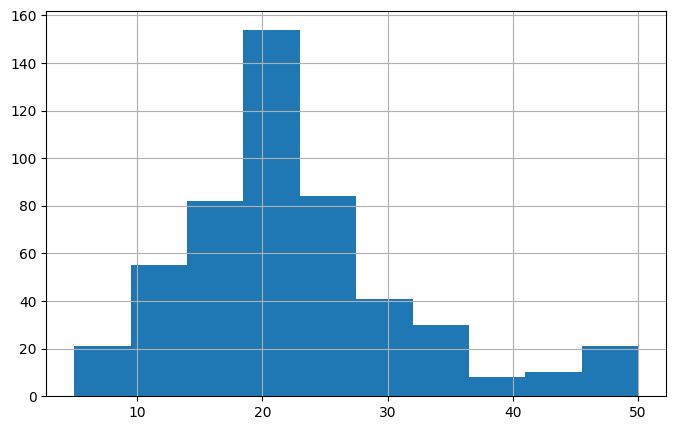

In [35]:
# One way to check whether data is normally distributed is plotting a histogram

plt.figure(figsize = (8,5))
boston_df.MEDV.hist();      # MEDV is Target/Output Variable

**Observation** - above histogram shows that data is not normally distributed due to tail at end.

Further check is performing a p-value hypothesis check via normaltest

p value = above 0.05 --> not enough evidence to reject the claim of normality (data looks normal)
p value = below 0.05 --> evidence found to reject the claim of normality (data does not look normal)

In [6]:
# Importing scipy (stats lib.) library for normaltest

from scipy.stats import normaltest

statistic,pvalue = normaltest(boston_df.MEDV.values)

print(f'The p-value for column MEDV values is {pvalue}.')

The p-value for column MEDV values is 1.7583188871696098e-20.


**Observation** - 
Above results presents p-value with 19 zeros before 1.75, implying that p-value is smaller than 0.05, hence, there is evidence to reject the claim of normality OR **data is not normally distributed**.

**Prediction vs Interpretation**

Prediction-focused ML

* Normality matters much less.
* If predictions are accurate, you're happy.

Interpretation-focused statistics

* Normality matters more.
* You want trustworthy conclusions about relationships.

#### First Transformation - 
Tranforming Target (Y variable) via **log** to aid normalising the data values.

**np.log(y)**

What it does:

Compresses large values much more than small values.
Reduces right-skew.

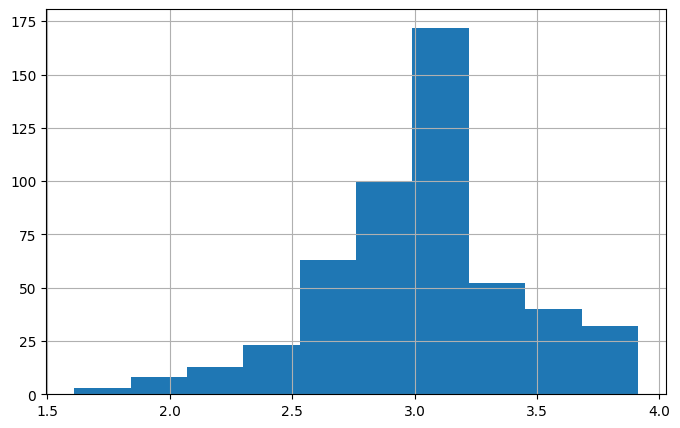

In [36]:
log_MEDV = np.log(boston_df.MEDV)

plt.figure(figsize = (8,5))
log_MEDV.hist();

In [8]:
print(f'The p-value for log_MEDV values is {normaltest(log_MEDV).pvalue}.')

The p-value for log_MEDV values is 0.00018245472768345196.


**Observation** - p-value still not over 0.05 parameter, hence **data still not normalised**.

#### Second Transformation - 
Tranforming Target (Y variable) via **sqrt** to aid normalising the data values.

**np.sqrt(y)**

What it does:

Compresses large values, but less aggressively than log.
Mild skew correction.

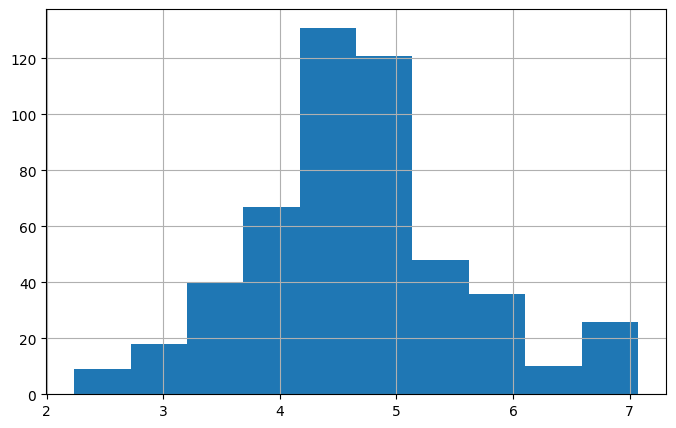

In [37]:
sqrt_MEDV = np.sqrt(boston_df.MEDV)

plt.figure(figsize = (8,5))
sqrt_MEDV.hist();

In [10]:
print(f'The p-value for sqrt_MEDV values is {normaltest(sqrt_MEDV).pvalue}.')

The p-value for sqrt_MEDV values is 3.558645701429252e-05.


**Observation** - p-value still not over 0.05 parameter (0.0000355), hence **data is not normalised**.

#### Third Transformation - 
Tranforming Target (Y variable) via **boxcox** to aid normalising the data values.

from scipy.stats import **boxcox**

**y_transformed, lambda_ = boxcox(y)**

What it does:

Automatically finds the best power transformation.
Tries many transformations and chooses the one that makes data closest to normal.

Boxcox has 2 values, y_transformed at position 0 and lambda_ at position 1 (0.21662091371265346).




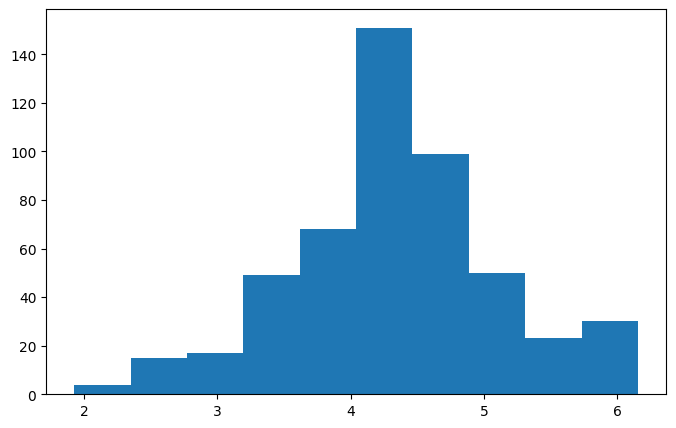

In [40]:
from scipy.stats import boxcox

boxcox_MEDV = boxcox(boston_df.MEDV)

print(f'Boxcox has 2 values, y_transformed at position 0 and lambda_ at position 1 ({boxcox_MEDV[1]}).')
print('\n')

plt.figure(figsize = (8,5))
plt.hist(boxcox_MEDV[0]);

In [12]:
print(f'The p-value for boxcox_MEDV values is {normaltest(boxcox_MEDV[0]).pvalue}.')

The p-value for boxcox_MEDV values is 0.10468867128448933.


**Observation** - p-value is over 0.05 parameter, hence **data is normalised** with boxcox transformation.

## 2. Testing Regression

### Importing Libraries

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures)

In [14]:
# Splitting boston_df into x and y variables

y = boston_df['MEDV']
# only MEDV column

x = boston_df.drop('MEDV', axis = 1)
# all columns except MEDV

### Create Polynomial Features

**PolynomialFeatures**(degree = 2, include_bias = False)

degree = 2 creates x1, x2, x1², x1*x2, x2²

include_bias = adds a column of 1s, normally set to False since Linear Regression already handles the intercept

What it does:

Creates new features from existing features so the model can learn curved/non-linear relationships.

In [15]:
pf = PolynomialFeatures(degree = 2, include_bias = False)

x_pf = pf.fit_transform(x)

In [16]:
print(f'The shape of x variable is {x.shape}, while x_pf comes to {x_pf.shape} 91 more column than original dataset.')

The shape of x variable is (506, 13), while x_pf comes to (506, 104) 91 more column than original dataset.


### Train-Test-Split

**train_test_split**(x_pf, y, train_size = 0.7, random_state = 99)

train_size = 0.7 assign 70% data for training and rest for testing

random_state = 101 stores the randomly generated split in seed 101

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x_pf, y, train_size = 0.7, random_state = 101)

In [18]:
print(f'After split X_train shape comes to 70% {X_train.shape} of x_pf variable shape {x_pf.shape}.')
print(f'Similarly y_train shape comes to 70% {y_train.shape} of y shape {y.shape}.')

After split X_train shape comes to 70% (354, 104) of x_pf variable shape (506, 104).
Similarly y_train shape comes to 70% (354,) of y shape (506,).


### Fit StandardScalar on X_train as before

Standardizes each feature to have:

Mean = 0
; Standard Deviation = 1

Polynomial features can create very large values.
StandardScaler brings them to a similar scale.

In [19]:
ss = StandardScaler()

X_train_ss = ss.fit_transform(X_train)

In [20]:
X_train_ss.shape

(354, 104)

### Transforming y_train values using boxcox

In [21]:
y_transformed, lambda_ = boxcox(y_train)

y_train_bc = y_transformed

In [22]:
y_train_bc.shape

(354,)

In [39]:
lr = LinearRegression()

lr.fit(X_train_ss, y_train_bc);

In [24]:
# Also fit StandardScalar on X_test and using LinearRegression to predict y using X_test

X_test_ss = ss.transform(X_test)

y_pred_bc = lr.predict(X_test_ss)

In [25]:
print(f'The X_test variable has shape {X_test.shape} showing it has 152 rows and likewise y_pred_bc (Predicted y values).shape{y_pred_bc.shape} has same number of rows.')

The X_test variable has shape (152, 104) showing it has 152 rows and likewise y_pred_bc (Predicted y values).shape(152,) has same number of rows.


### Inverse Transformation

Comparing y_test values with y_pred_bc to check the proximity of predicted values.

In [26]:
y_test[:5]

195    50.0
4      36.2
434    11.7
458    14.9
39     30.8
Name: MEDV, dtype: float64

In [27]:
y_pred_bc[:5]

array([5.64438474, 4.55603445, 3.57969283, 3.55681369, 4.53613434])

**Observation** - The Predicted values do not come close to actual values from test split, this is because the boxcox figures were chosen for normal distribution not the actual values.

In [28]:
# Importing Library for Inverse Boxcox

from scipy.special import inv_boxcox

In [29]:
# MEDV column from boston_df already transformed via boxcox earlier

boxcox_MEDV_y = boxcox_MEDV[0]
boxcox_MEDV_lam = boxcox_MEDV[1]

print(boxcox_MEDV_y[:5])
print(boxcox_MEDV_lam)

[4.57293647 4.36558176 5.33694287 5.2549546  5.42860703]
0.21662091371265346


In [30]:
# Inserting the boxcox values into inverser_boxcox

inv_boxcox_MEDV = inv_boxcox(boxcox_MEDV_y, boxcox_MEDV_lam)

In [31]:
inv_boxcox_MEDV[:5]

array([24. , 21.6, 34.7, 33.4, 36.2])

In [32]:
boston_df['MEDV'].values[:5]

array([24. , 21.6, 34.7, 33.4, 36.2])

**Observation** - Naturally, the inv_boxcox_MEDV values of boxcox_MEDV revert back to original values from boston_df['MEDV'].

In [33]:
y_pred_tran = inv_boxcox(y_pred_bc,lambda_)  # lambda_ taken from boxcox(y_train)

r2_score(y_test,y_pred_tran)

0.8275813083025669

**Observation** - The R2_score comes to roughly 0.82.

### Transforming y_train values without using boxcox

In [34]:
lr.fit(X_train_ss, y_train)
lr_pred = lr.predict(X_test_ss)

r2_score(y_test,lr_pred)

0.8535857918236953

**Key Takeaway** - The R2_score without boxcox performed on y_pred comes to roughly 0.85. No transformation performed better.